In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import preliz as pz
from IPython.core.pylabtools import figsize



In [2]:
az. style.use('arviz-grayscale')
from cycler import cycler
default_cycler = cycler(color=['#000000', '#6a6a6a', '#bebebe', '#2a2eec'])
plt.rc('axes', prop_cycle=default_cycler)
plt.rc('figure', dpi=300)

In [3]:
np.random.seed(123)
trials = 4
theta_real = 0.35 # unknown value in a real experiment
data = pz.Binomial(n=1, p=theta_real).rvs(trials)
data

array([0, 0, 0, 0])

In [4]:
with pm.Model() as our_first_model:
    theta = pm.Beta('theta', alpha=1.0, beta=1.0)
    y = pm.Bernoulli('y', p=theta,observed=data)
    idata = pm.sample(draws=1000, chains=4, tune=1000, random_seed=4591)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


<function matplotlib.pyplot.savefig(*args, **kwargs) -> 'None'>

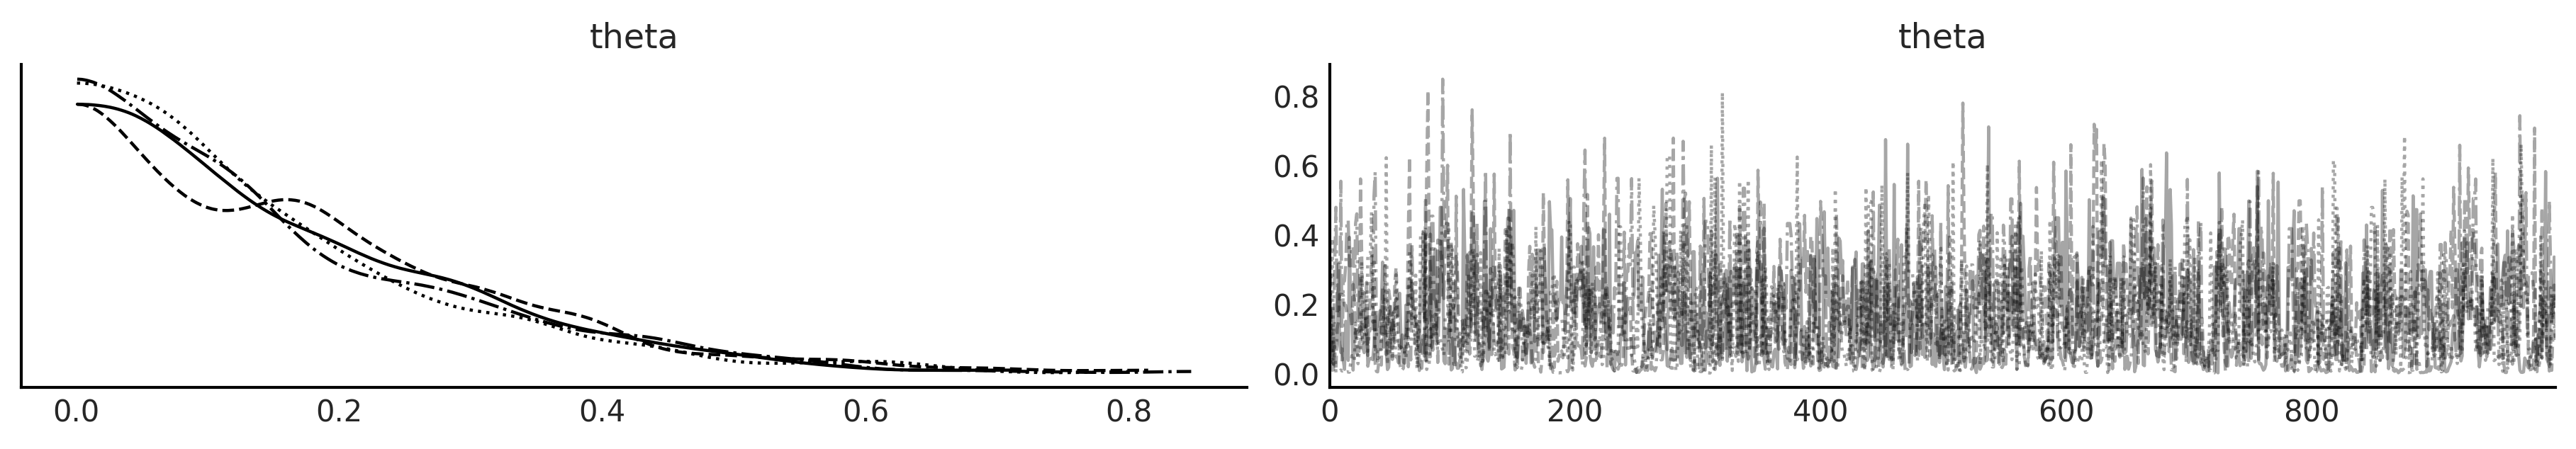

In [5]:
az.plot_trace(idata)
plt.savefig

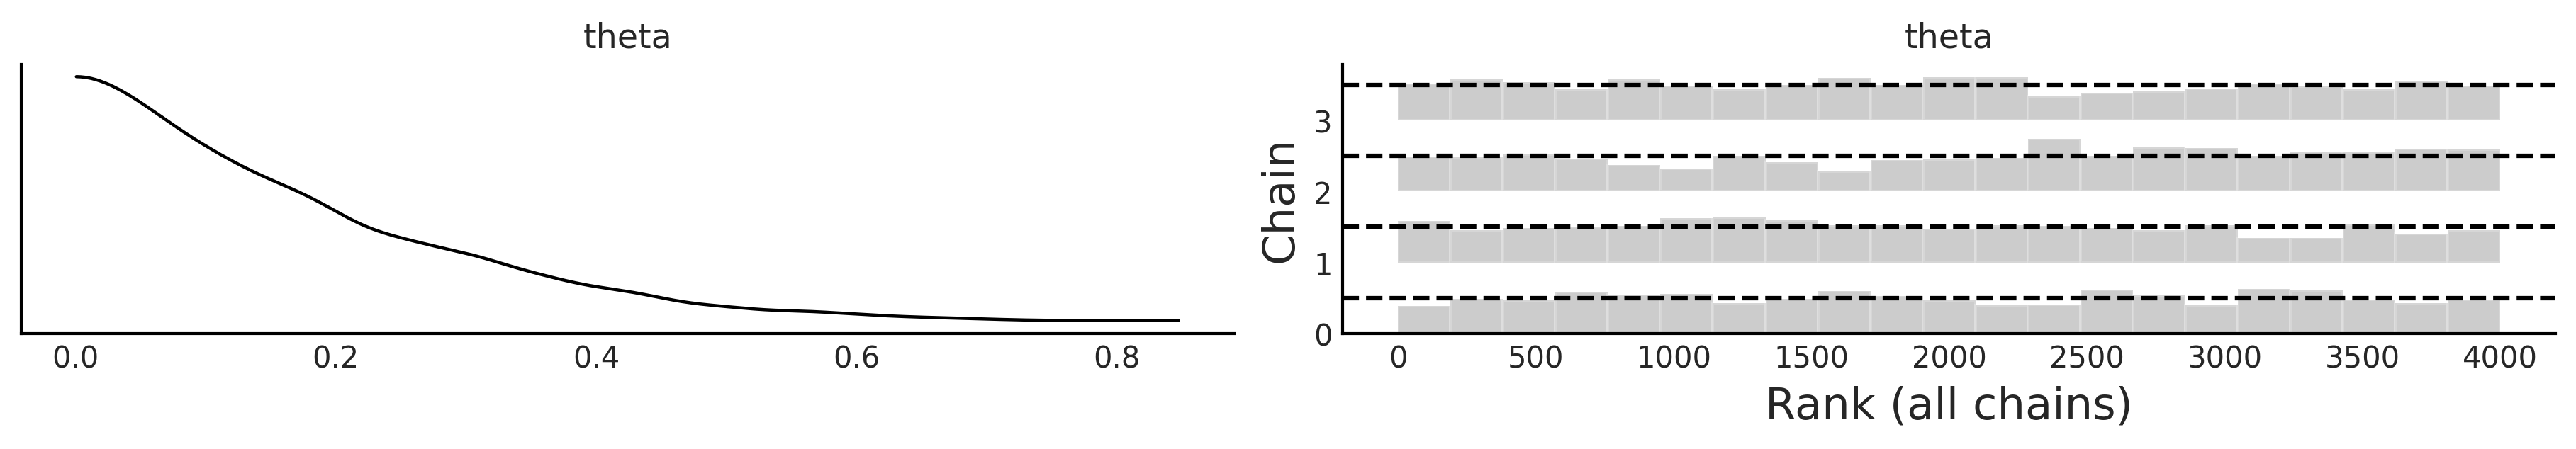

In [6]:
az.plot_trace(idata, kind='rank_bars', combined=True, rank_kwargs={'colors': 'k'})
plt.savefig('fig/idata_rank.png')

In [7]:
az.summary(idata, kind='stats').round(2)

,mean,sd,hdi_3%,hdi_97%
theta,0.16,0.14,0.0,0.42


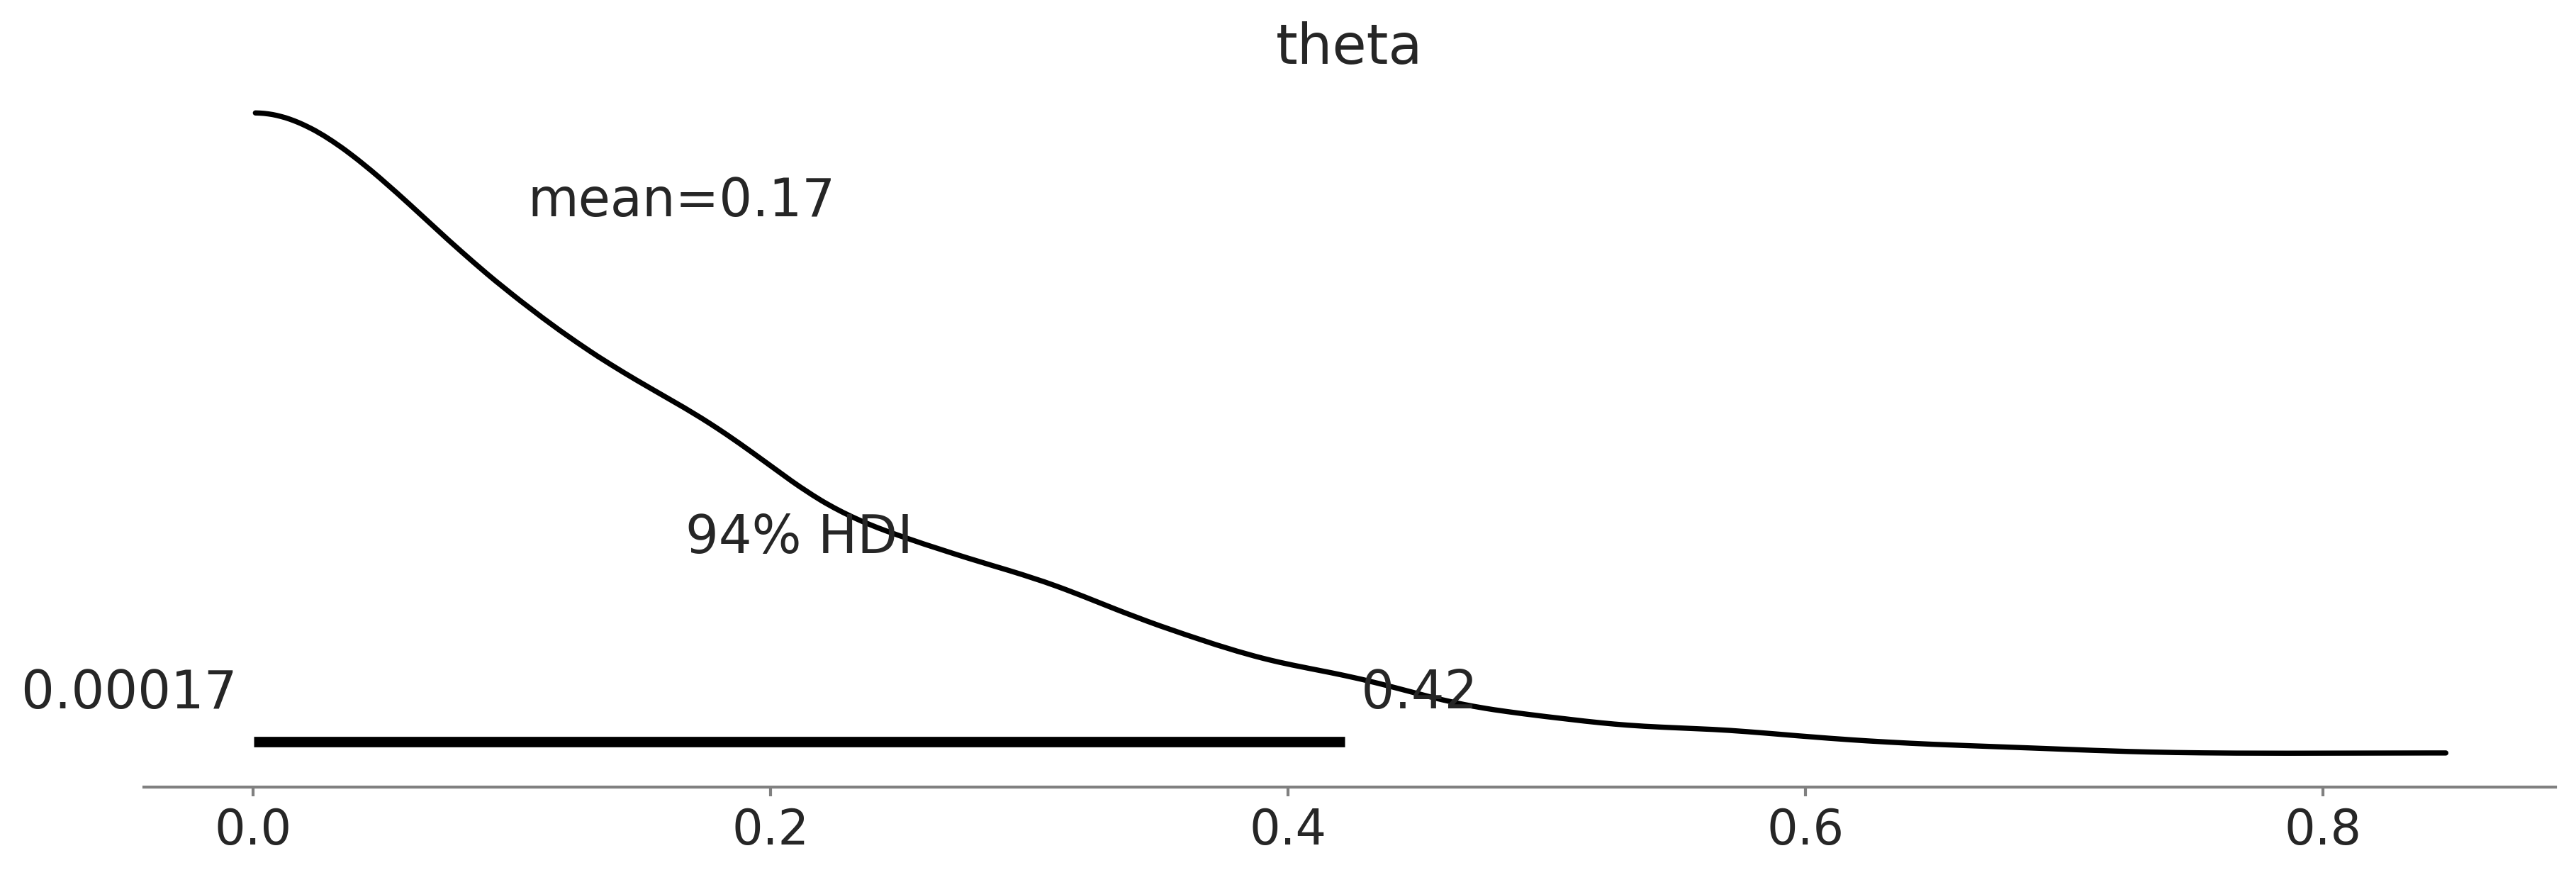

In [8]:
az.plot_posterior(idata, figsize=(12, 4))
plt.savefig('fig/idata_posterior.png')

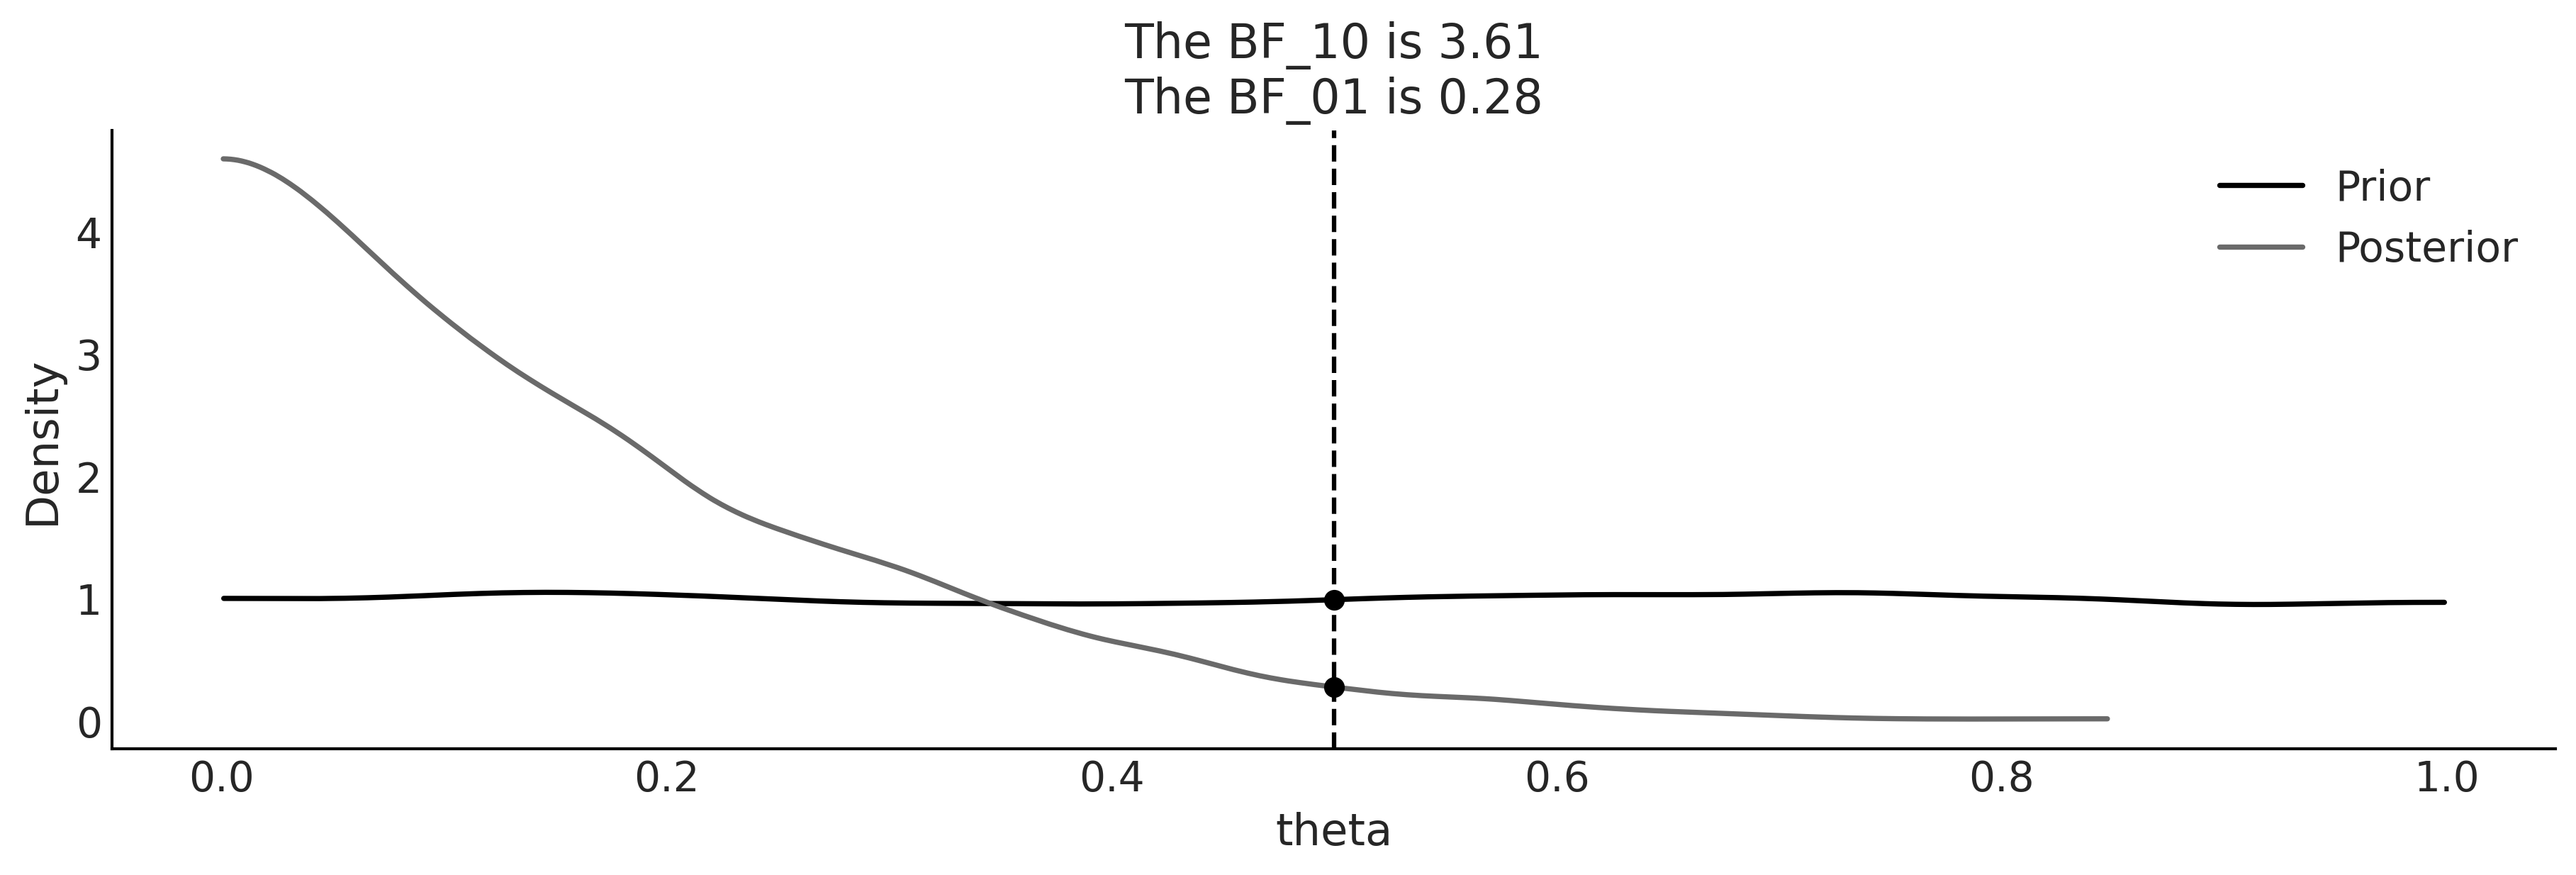

In [9]:
az.plot_bf(idata, var_name='theta', prior=np.random.uniform(0, 1, 10000), ref_val=0.5, figsize=(12, 4))
plt.savefig('fig/idata_bf.png')

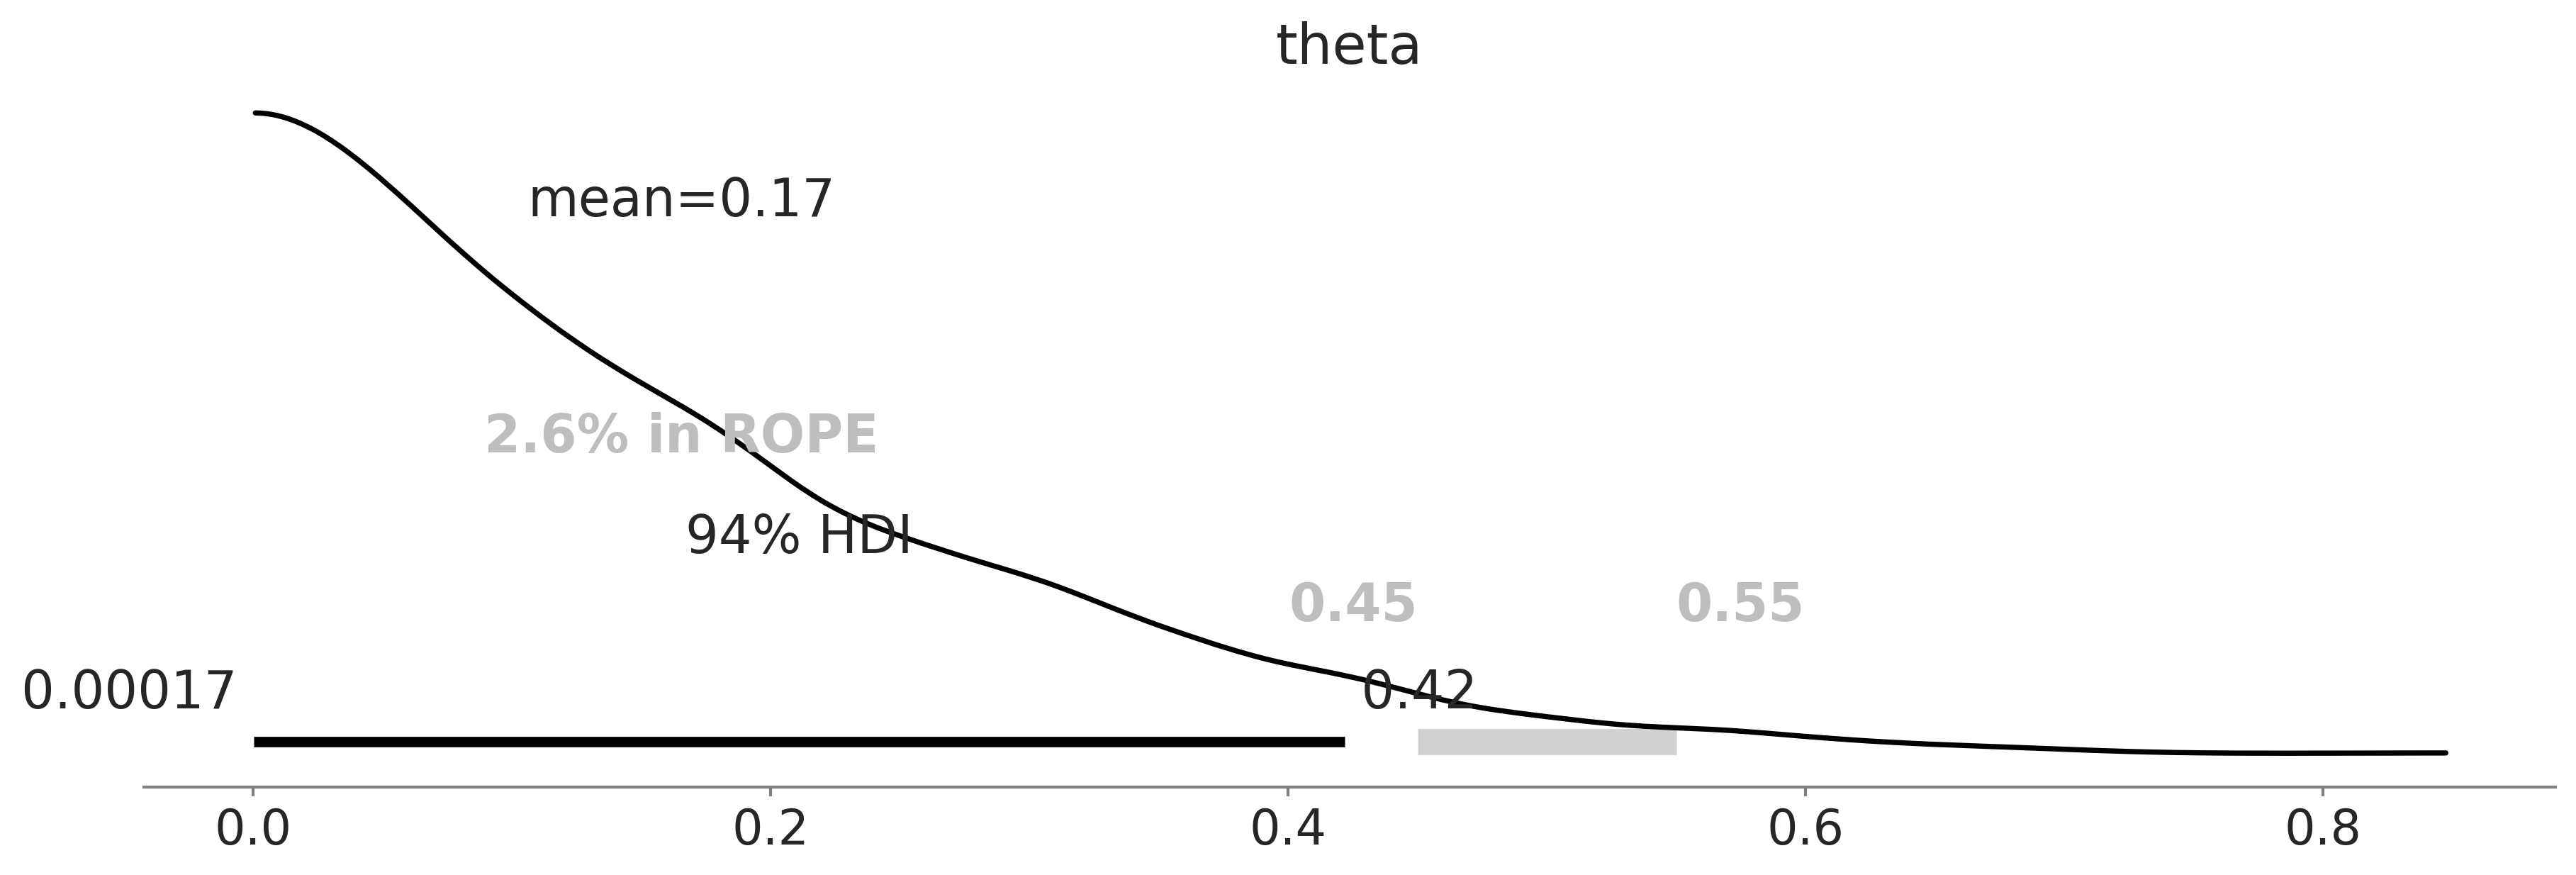

In [10]:
az.plot_posterior(idata, rope=[0.45, 0.55], figsize=(12, 4))
plt.savefig('fig/idata_posterior_rope.png')

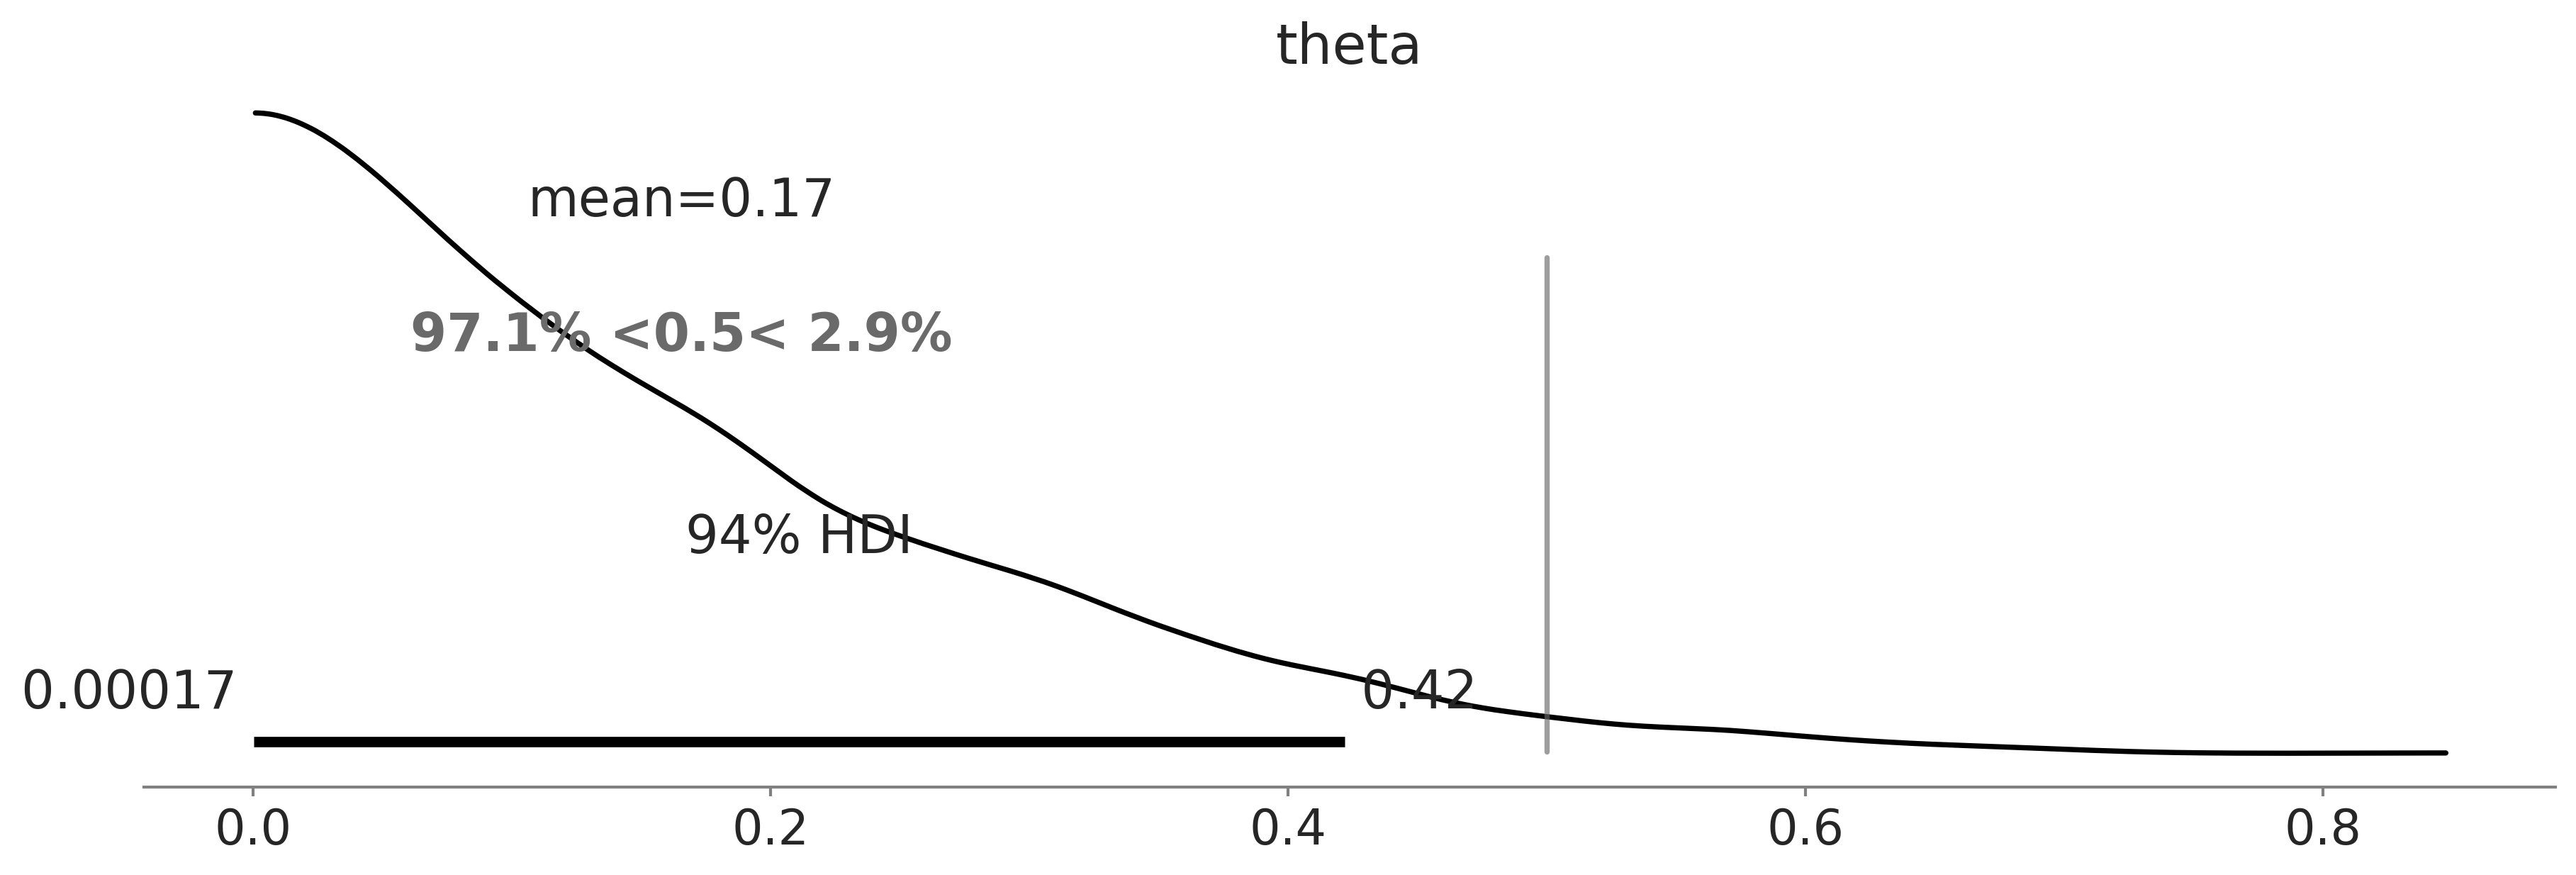

In [11]:
az.plot_posterior(idata, ref_val=0.5, figsize=(12, 4))
plt.savefig('fig/udata_posterior_ref.png')

In [12]:
grid = np.linspace(0, 1, 200)
theta_pos = idata.posterior['theta']
lossf_a = [np.mean(abs(i - theta_pos)) for i in grid]
lossf_b = [np.mean((i - theta_pos)**2) for i in grid]
np.argmin(lossf_a)

26

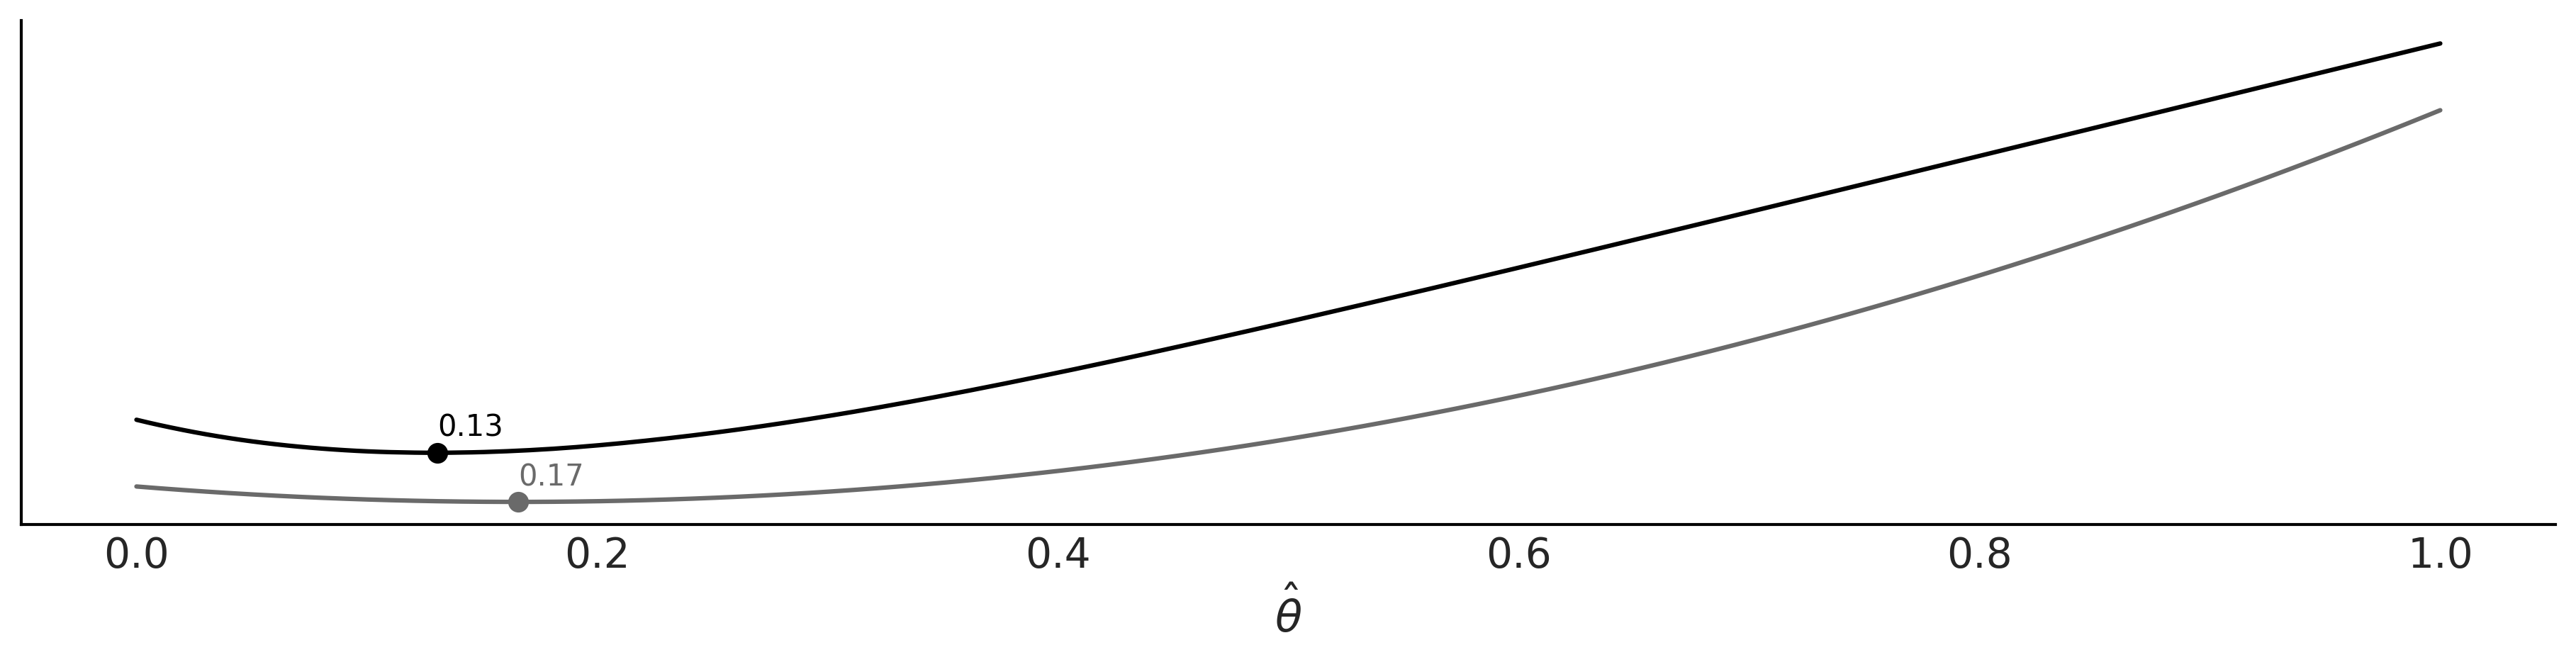

In [13]:
grid = np.linspace(0, 1, 200)
theta_pos = idata.posterior['theta']
lossf_a = [np.mean(abs(i - theta_pos)) for i in grid]
lossf_b = [np.mean((i - theta_pos)**2) for i in grid]

_, ax = plt.subplots(figsize=(12, 3))
for lossf, c in zip([lossf_a, lossf_b], ['C0', 'C1']):
    mini = np.argmin(lossf)
    ax.plot(grid, lossf, c)
    ax.plot(grid[mini], lossf[mini], 'o', color=c)
    ax.annotate('{:.2f}'.format(grid[mini]), (grid[mini], lossf[mini] + 0.03), color=c)
    ax.set_yticks([])
    ax.set_xlabel(r'$\hat \theta$')

plt.savefig('fig/idata_loss.png')

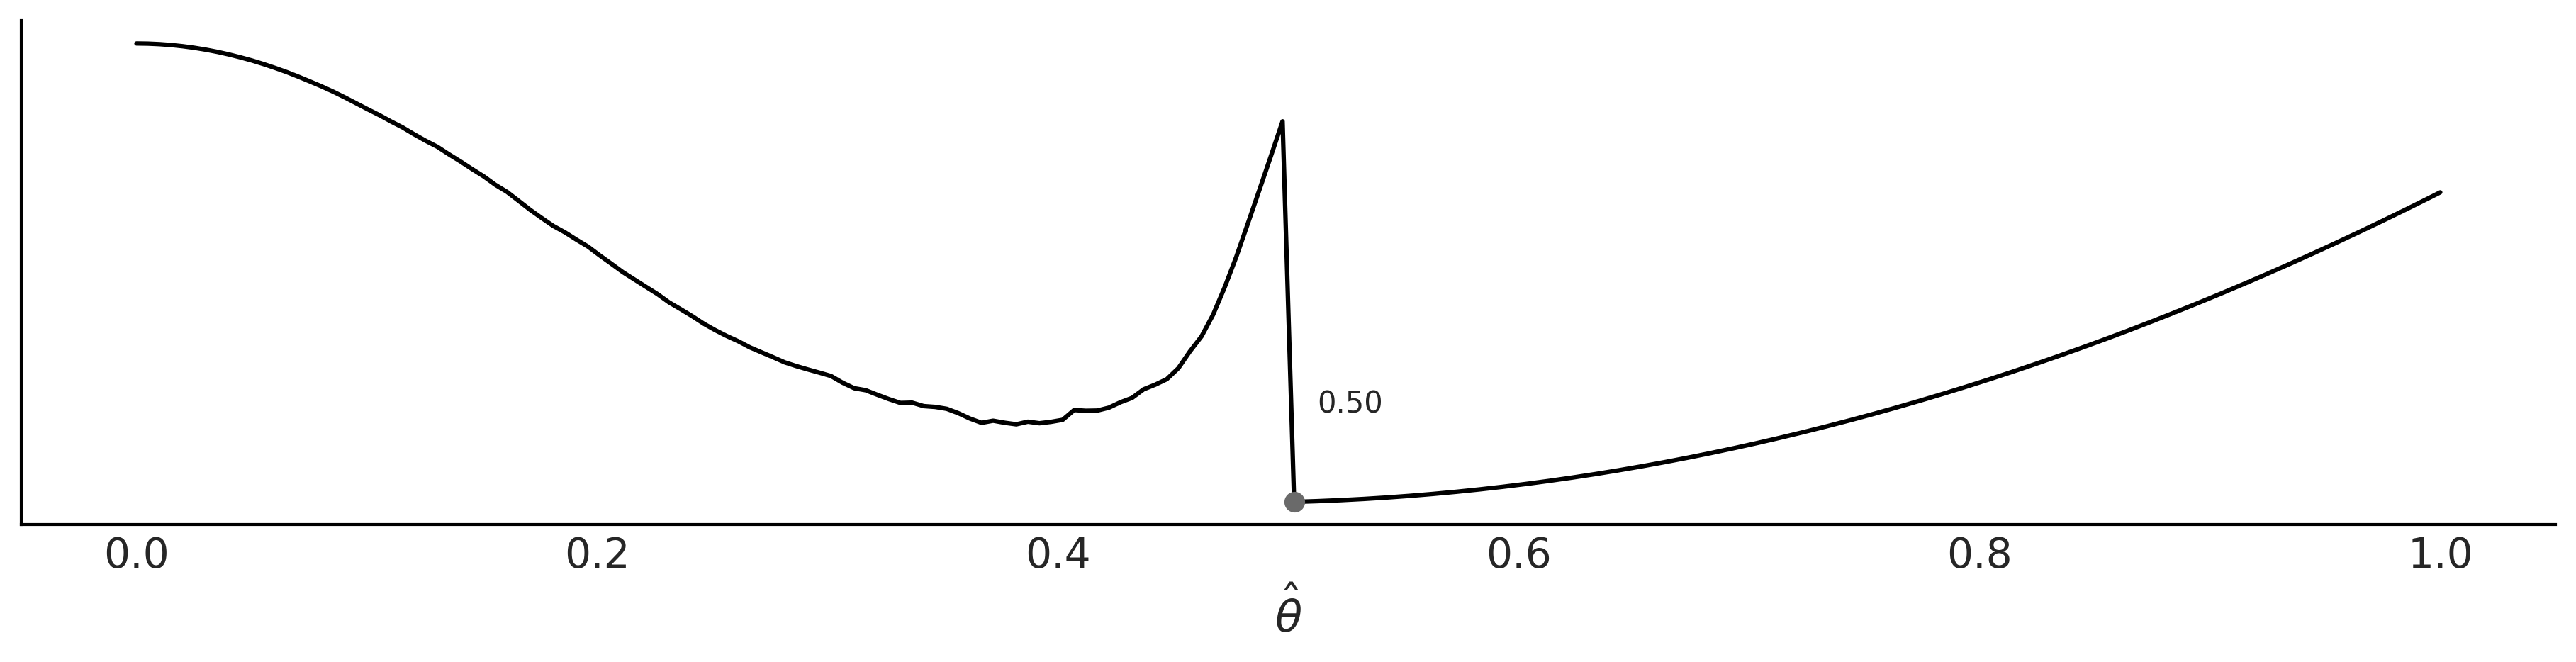

In [19]:
lossf = []
for i in grid:
    if i < 0.5:
        f = 1/np.median(theta_pos / np.abs(i**2 - theta_pos))
    else:
        f = np.mean((i - theta_pos)**2 + np.exp(-i)) - 0.25
    lossf.append(f)

mini = np.argmin(lossf)

_, ax = plt.subplots(figsize=(12, 3))
ax.plot(grid, lossf)
ax.plot(grid[mini], lossf[mini], 'o')
ax.annotate('{:.2f}'.format(grid[mini]), (grid[mini] +0.01, lossf[mini] + 0.1))
ax.set_yticks([])
ax.set_xlabel(r'$\hat \theta$')
plt.savefig('fig/idata_loss2.png')

Data: [51.06 55.12 53.73 50.24 52.05 56.4  48.45 52.34 55.65 51.49 51.86 63.43
 53.   56.09 51.93 52.31 52.33 57.48 57.44 55.14 53.93 54.62 56.09 68.58
 51.36 55.47 50.73 51.94 54.95 50.39 52.91 51.5  52.68 47.72 49.73 51.82
 54.99 52.84 53.19 54.52 51.46 53.73 51.61 49.81 52.42 54.3  53.84 53.16]



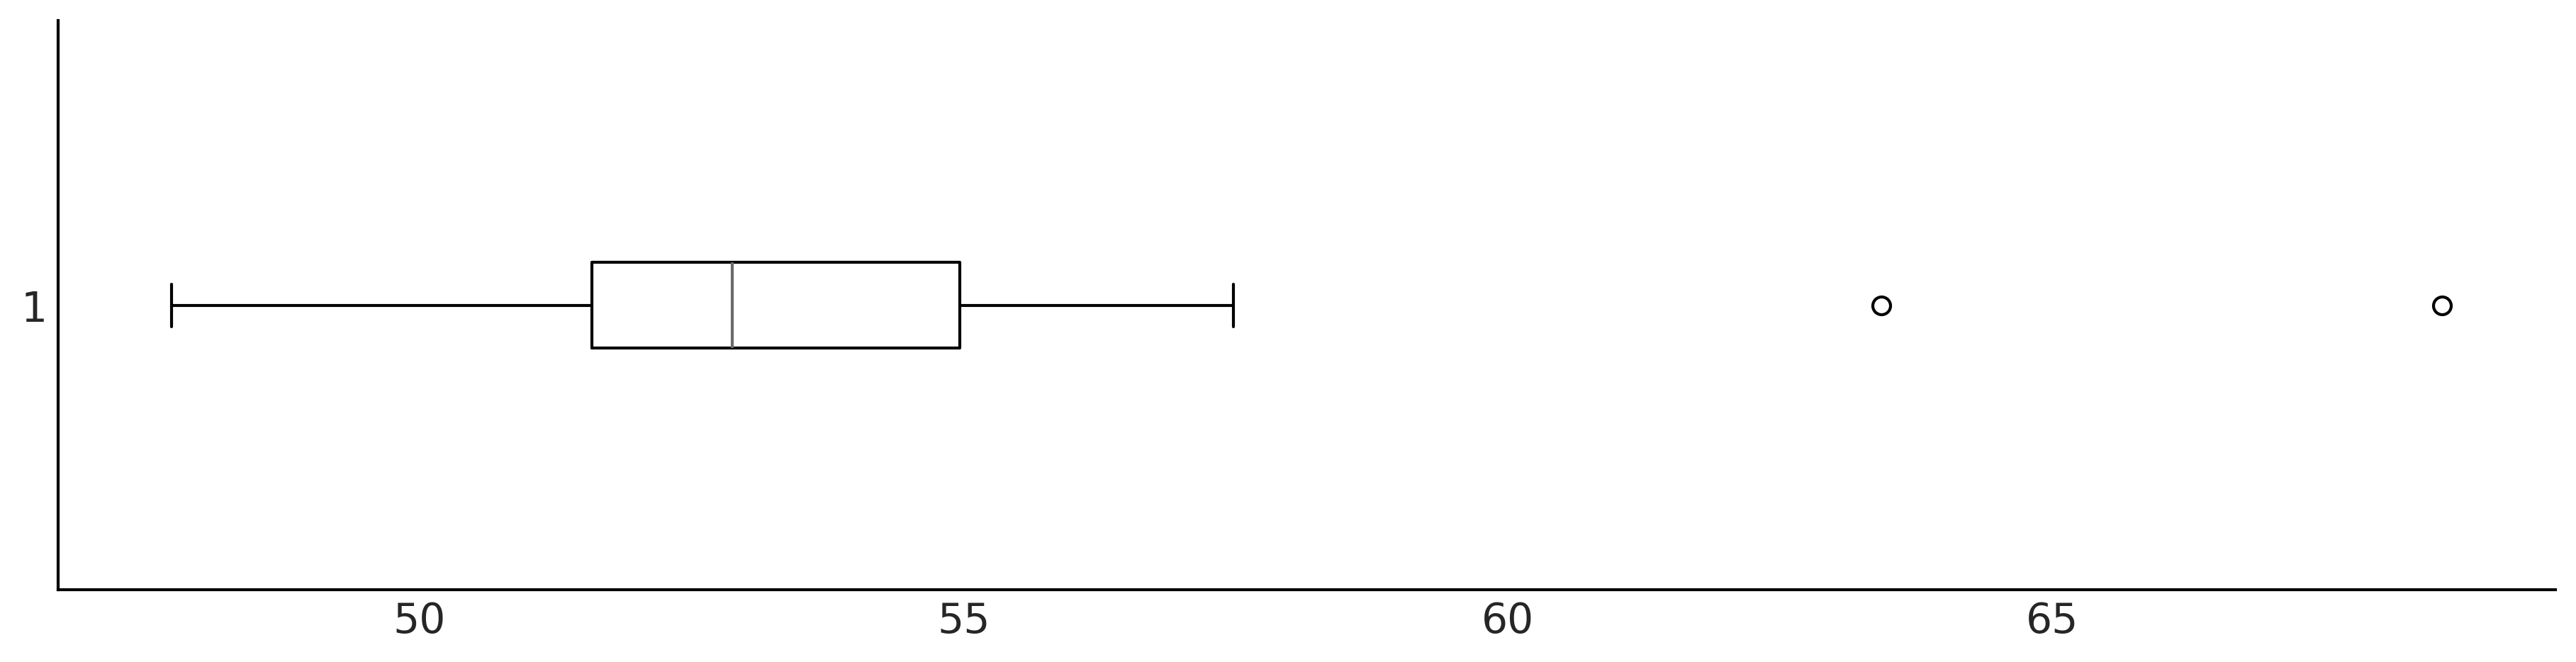

In [23]:
data = np.loadtxt('../code/data/chemical_shifts.csv')
print(f'Data: {data}')
print()

_,ax = plt.subplots(figsize=(12, 3))
ax.boxplot(data, vert=False)
plt.savefig('fig/boxplot.png')

In [24]:
with pm.Model() as model_g:
    µ = pm.Uniform('µ', lower=40, upper=70)
    σ = pm.HalfNormal('σ', sigma=5)
    𝛄 = pm.Normal('𝛄', mu=µ, sigma=σ, observed=data)
    idata_g = pm.sample(random_seed=4591)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [µ, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


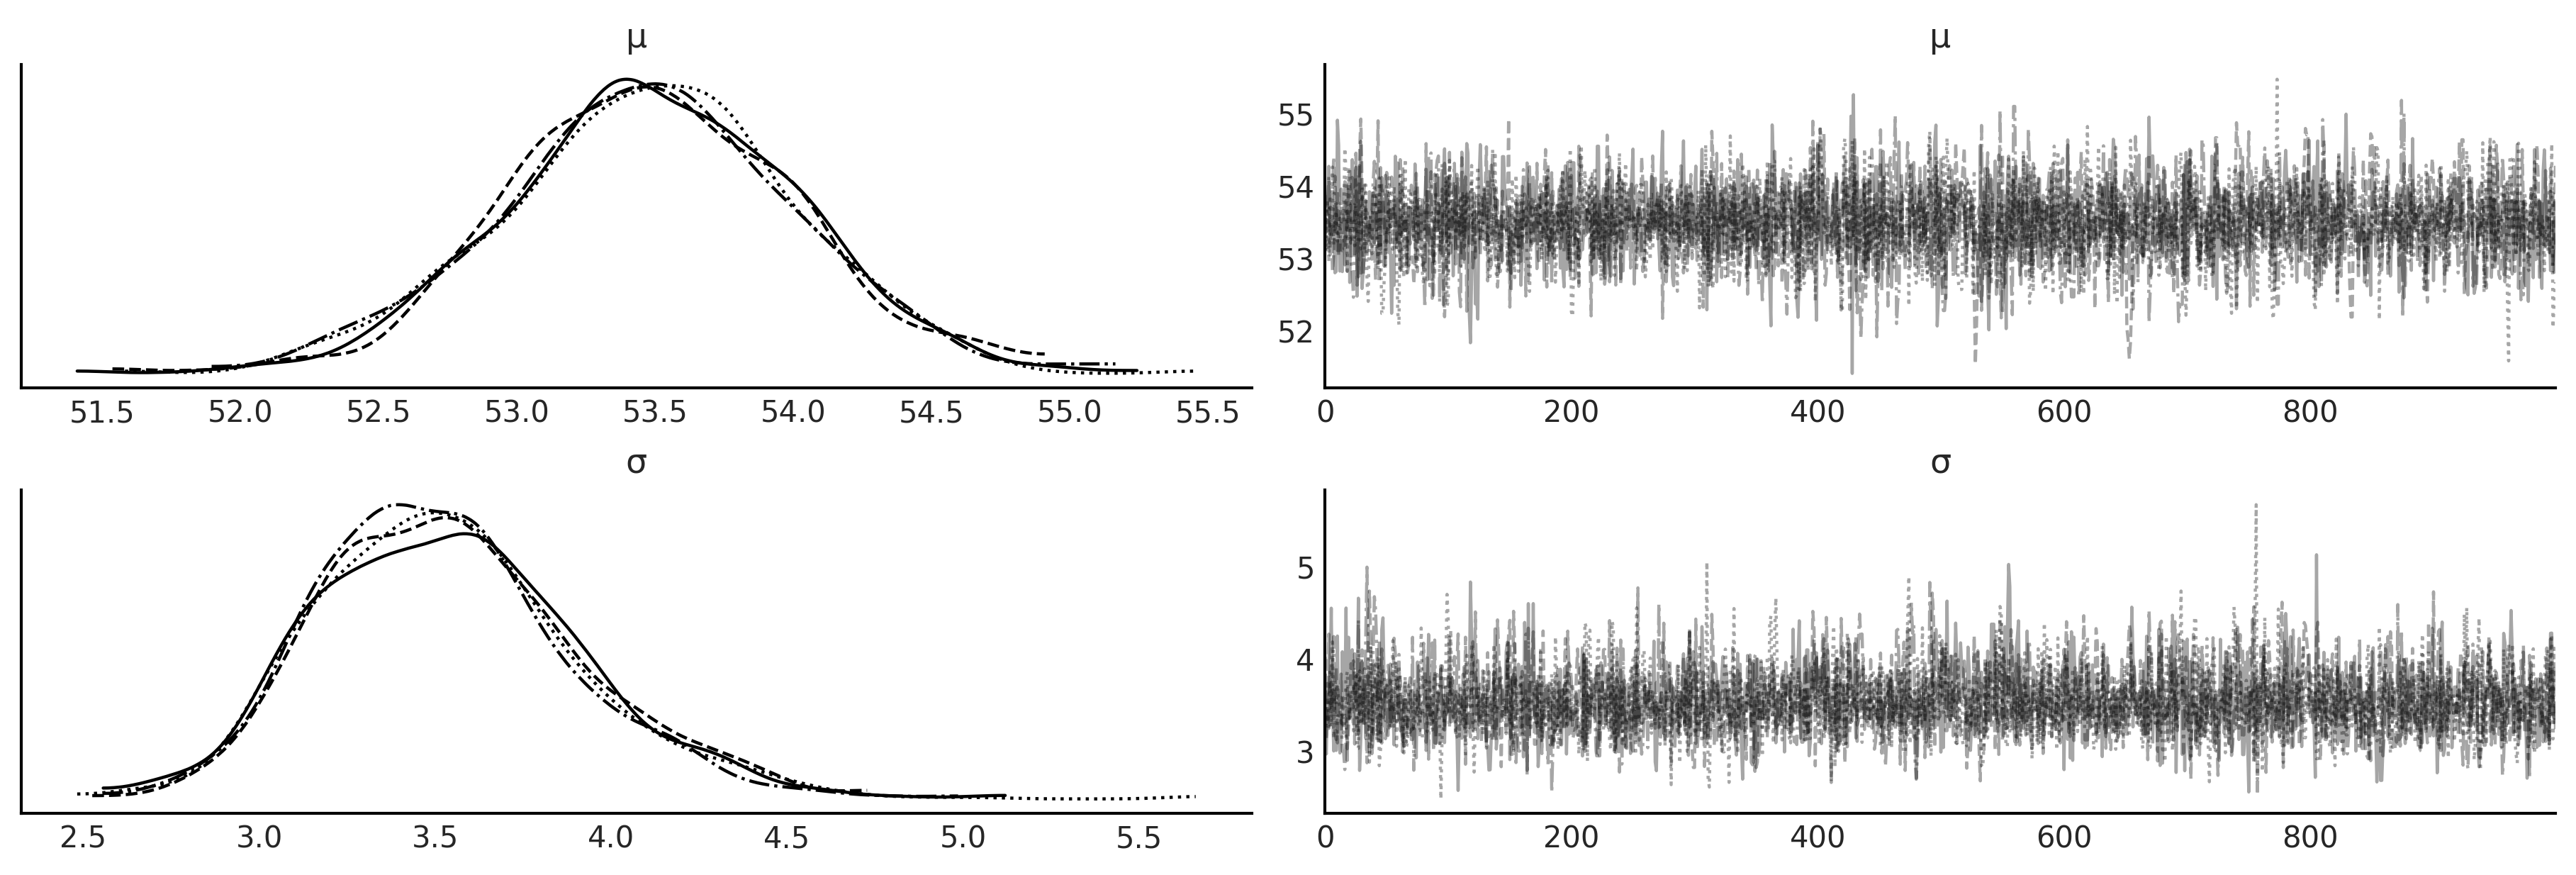

In [25]:
az.plot_trace(idata_g)
plt.savefig('fig/idata_g_trace.png')

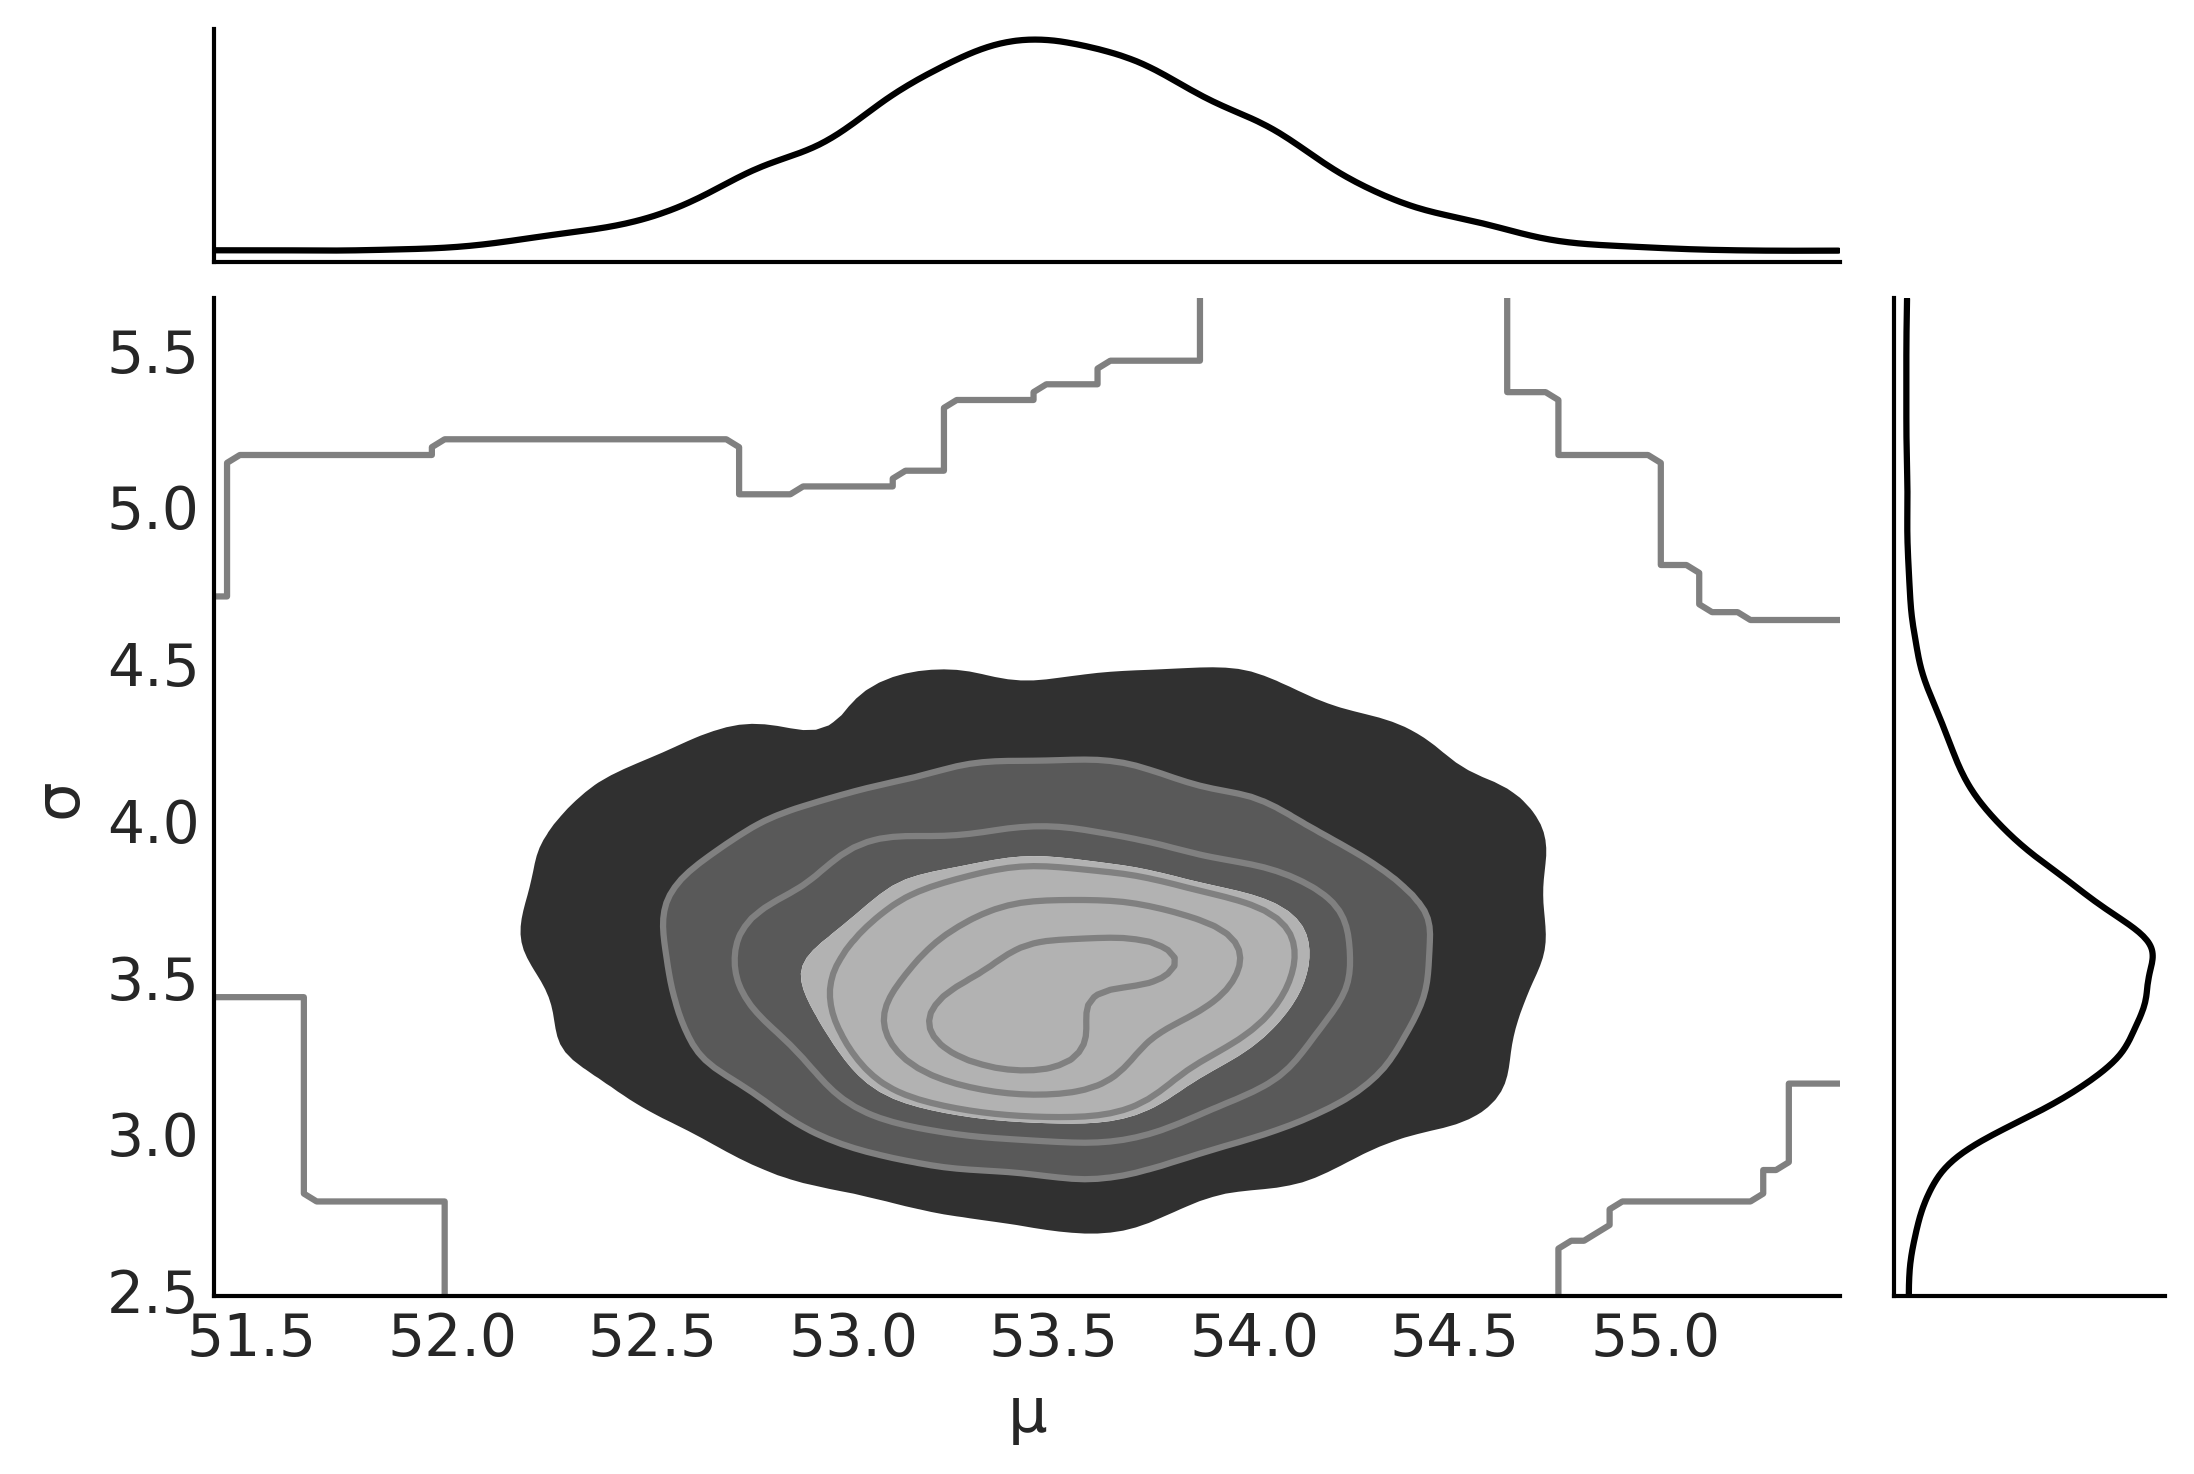

In [27]:
az.plot_pair(idata_g, kind='kde', marginals=True)
plt.savefig('fig/idata_g_pair.png')

In [28]:
az.summary(idata_g, kind='stats').round(2)

,mean,sd,hdi_3%,hdi_97%
µ,53.48,0.52,52.58,54.56
σ,3.53,0.36,2.94,4.30
